# ESC-50 1D CNN for Environmental Sound Classification

## Setup and Imports

In [1]:
import torch
import torch.nn as nn
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import librosa
import warnings
warnings.filterwarnings('ignore')

from src.data import ESC50Dataset, load_audio, fix_length, normalize
from src.model import SoundCNN1D
from src.train import (
    set_seed, make_dataloader, train_one_epoch, evaluate, run_fold, run_cross_validation
)

base_path = Path('.')
csv_file = base_path / 'ESC-50-master' / 'meta' / 'esc50.csv'
audio_folder = base_path / 'ESC-50-master' / 'audio'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', device)
print('CSV:', csv_file.exists())
print('Audio folder:', audio_folder.exists())

Device: cpu
CSV: True
Audio folder: True


## Data Exploration

In [2]:
meta = pd.read_csv(csv_file)
print('Metadata shape:', meta.shape)
print('\nFirst few rows:')
print(meta.head())
print('\nClasses:')
print('Number of unique classes:', meta['target'].nunique())
print('Samples per class:')
print(meta['target'].value_counts().sort_index())

Metadata shape: (2000, 7)

First few rows:
            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A

Classes:
Number of unique classes: 50
Samples per class:
target
0     40
1     40
2     40
3     40
4     40
5     40
6     40
7     40
8     40
9     40
10    40
11    40
12    40
13    40
14    40
15    40
16    40
17    40
18    40
19    40
20    40
21    40
22    40
23    40
24    40
25    40
26    40
27    40
28    40
29    40
30    40
31    40
32    40
33    40
34    40
35    40
36    40
37    40
38    40
39    40
40    40
41    40
42    40
43    40
44    40
45    40
46    40
47    40
48    40
49    40
Name

Sample filename: 1-100032-A-0.wav
Sample label: 0
Sample category: dog
Waveform shape: torch.Size([1, 80000])
Waveform min: -0.9665362238883972
Waveform max: 1.0


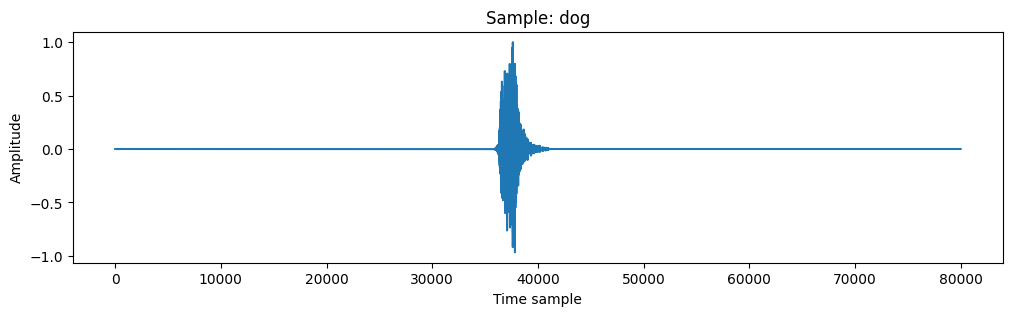

In [3]:
dataset_fold1 = ESC50Dataset(csv_file, audio_folder, folds=[1], augment=False)
sample = dataset_fold1[0]

print('Sample filename:', sample['filename'])
print('Sample label:', sample['label'])
print('Sample category:', sample['category'])
print('Waveform shape:', sample['waveform'].shape)
print('Waveform min:', sample['waveform'].min().item())
print('Waveform max:', sample['waveform'].max().item())

plt.figure(figsize=(12, 3))
plt.plot(sample['waveform'].squeeze().numpy())
plt.title(f'Sample: {sample["category"]}')
plt.xlabel('Time sample')
plt.ylabel('Amplitude')
plt.show()

## Model Test

In [4]:
model = SoundCNN1D(num_classes=50)
print('Model:')
print(model)

dummy_input = torch.randn(2, 1, 80000)
with torch.no_grad():
    output = model(dummy_input)
print('\nDummy input shape:', dummy_input.shape)
print('Output shape:', output.shape)

Model:
SoundCNN1D(
  (layers): Sequential(
    (0): Conv1d(1, 16, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(9,), stride=(1,), padding=(4,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(4,))
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
   

## Train 1D CNN with 5-Fold Cross-Validation

In [5]:
set_seed(123)

cv_results = []
all_models = {}

for fold in range(1, 6):
    print(f'\n=== Fold {fold} ===')
    best_acc, best_model_state = run_fold(
        csv_file=csv_file,
        audio_folder=audio_folder,
        val_fold=fold,
        num_classes=50,
        batch_size=8,
        lr=1e-3,
        epochs=15,
    )
    cv_results.append(best_acc)
    all_models[fold] = best_model_state
    print(f'Fold {fold} best val accuracy: {best_acc:.4f}')

mean_cv = np.mean(cv_results)
std_cv = np.std(cv_results)
print(f'\n=== Cross-Validation Results ===')
print(f'Mean accuracy: {mean_cv:.4f}')
print(f'Std accuracy: {std_cv:.4f}')
print(f'Per-fold accuracies: {[round(x, 4) for x in cv_results]}')


=== Fold 1 ===
Fold 1 Epoch 1
  train_loss 3.4945 train_acc 0.0862
  val_loss 3.0386 val_acc 0.1275
Fold 1 Epoch 2
  train_loss 3.1 train_acc 0.1412
  val_loss 2.9053 val_acc 0.21
Fold 1 Epoch 3
  train_loss 2.8482 train_acc 0.2044
  val_loss 2.7826 val_acc 0.23
Fold 1 Epoch 4
  train_loss 2.7151 train_acc 0.2369
  val_loss 2.5545 val_acc 0.275
Fold 1 Epoch 5
  train_loss 2.539 train_acc 0.2925
  val_loss 2.4892 val_acc 0.305
Fold 1 Epoch 6
  train_loss 2.3825 train_acc 0.32
  val_loss 2.4175 val_acc 0.34
Fold 1 Epoch 7
  train_loss 2.3083 train_acc 0.33
  val_loss 2.3594 val_acc 0.37
Fold 1 Epoch 8
  train_loss 2.255 train_acc 0.3581
  val_loss 2.3177 val_acc 0.3525
Fold 1 Epoch 9
  train_loss 2.1165 train_acc 0.395
  val_loss 2.3493 val_acc 0.38
Fold 1 Epoch 10
  train_loss 2.0332 train_acc 0.4113
  val_loss 2.1407 val_acc 0.415
Fold 1 Epoch 11
  train_loss 1.9418 train_acc 0.4394
  val_loss 2.1705 val_acc 0.4275
Fold 1 Epoch 12
  train_loss 1.9088 train_acc 0.4425
  val_loss 2.0719

## Evaluate Best Model and Plot Confusion Matrix

Best fold: 4
Validation loss: 1.6343
Validation accuracy: 0.5550


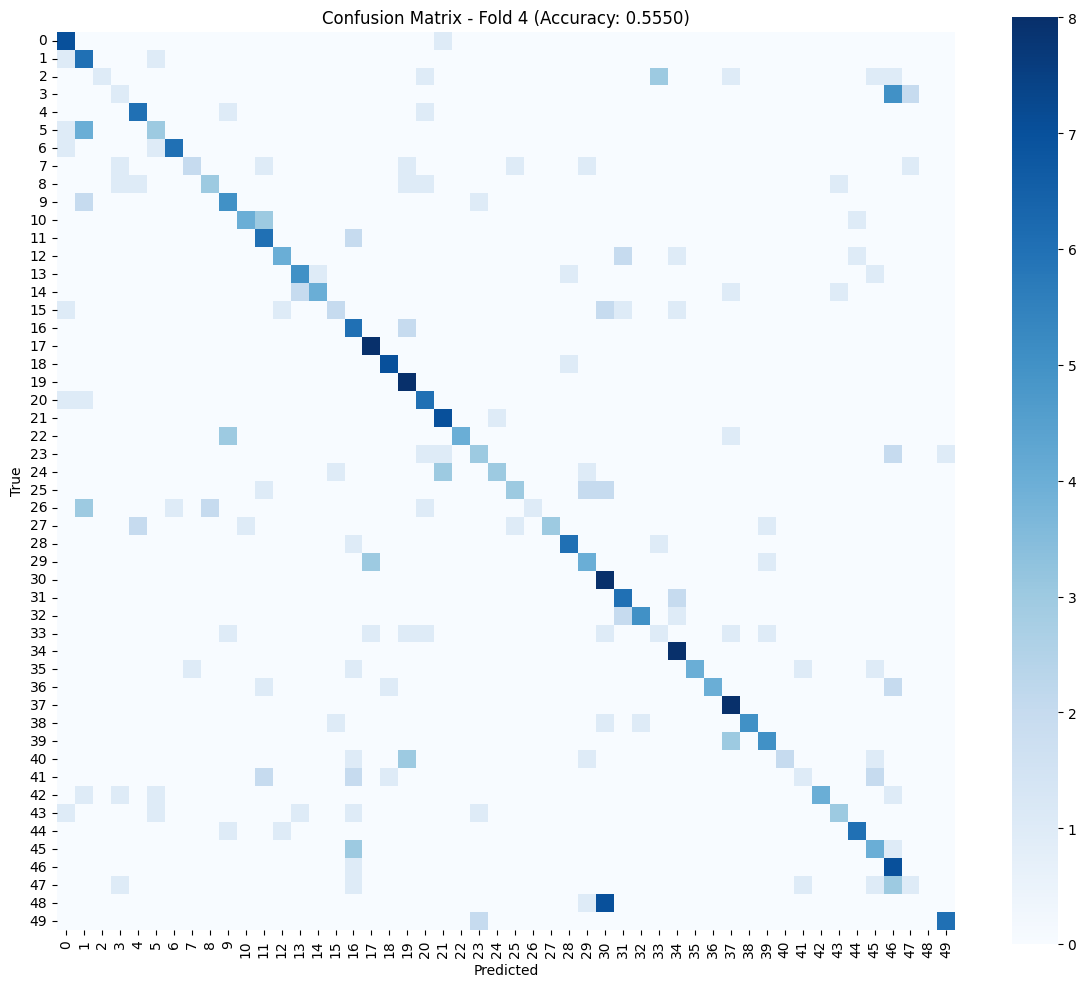

In [6]:
best_fold = np.argmax(cv_results) + 1
best_model = SoundCNN1D(num_classes=50).to(device)
best_model.load_state_dict(all_models[best_fold])

valid_loader = make_dataloader(csv_file, audio_folder, [best_fold], batch_size=8, augment=False)
loss_fn = nn.CrossEntropyLoss()
val_loss, val_acc, cm = evaluate(best_model, valid_loader, loss_fn, device)

print(f'Best fold: {best_fold}')
print(f'Validation loss: {val_loss:.4f}')
print(f'Validation accuracy: {val_acc:.4f}')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues', cbar=True, square=True, annot=False)
plt.title(f'Confusion Matrix - Fold {best_fold} (Accuracy: {val_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Class-wise Accuracy Analysis

In [7]:
class_acc = []
for i in range(50):
    if cm[i].sum() > 0:
        acc = cm[i, i] / cm[i].sum()
        class_acc.append(acc)
    else:
        class_acc.append(0.0)

class_acc = np.array(class_acc)

print('Class-wise accuracy:')
for i in range(50):
    cat = meta[meta['target'] == i]['category'].iloc[0]
    print(f'{i:2d} {cat:25s} {class_acc[i]:.4f}')

print(f'\nMean class accuracy: {class_acc.mean():.4f}')
print(f'\nWorst 5 classes:')
worst_idx = np.argsort(class_acc)[:5]
for idx in worst_idx:
    cat = meta[meta['target'] == idx]['category'].iloc[0]
    print(f'{idx:2d} {cat:25s} {class_acc[idx]:.4f}')

Class-wise accuracy:
 0 dog                       0.8750
 1 rooster                   0.7500
 2 pig                       0.1250
 3 cow                       0.1250
 4 frog                      0.7500
 5 cat                       0.3750
 6 hen                       0.7500
 7 insects                   0.2500
 8 sheep                     0.3750
 9 crow                      0.6250
10 rain                      0.5000
11 sea_waves                 0.7500
12 crackling_fire            0.5000
13 crickets                  0.6250
14 chirping_birds            0.5000
15 water_drops               0.2500
16 wind                      0.7500
17 pouring_water             1.0000
18 toilet_flush              0.8750
19 thunderstorm              1.0000
20 crying_baby               0.7500
21 sneezing                  0.8750
22 clapping                  0.5000
23 breathing                 0.3750
24 coughing                  0.3750
25 footsteps                 0.3750
26 laughing                  0.1250
27 brus

## Most Confused Class Pairs

In [8]:
confused = []
for i in range(50):
    for j in range(50):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], i, j))

confused.sort(reverse=True)

print('Top 10 confused pairs (true label -> predicted label):')
for count, true_class, pred_class in confused[:10]:
    true_cat = meta[meta['target'] == true_class]['category'].iloc[0]
    pred_cat = meta[meta['target'] == pred_class]['category'].iloc[0]
    print(f'{count} times: {true_class} ({true_cat}) -> {pred_class} ({pred_cat})')

Top 10 confused pairs (true label -> predicted label):
7 times: 48 (fireworks) -> 30 (door_wood_knock)
5 times: 3 (cow) -> 46 (church_bells)
4 times: 5 (cat) -> 1 (rooster)
3 times: 47 (airplane) -> 46 (church_bells)
3 times: 45 (train) -> 16 (wind)
3 times: 40 (helicopter) -> 19 (thunderstorm)
3 times: 39 (glass_breaking) -> 37 (clock_alarm)
3 times: 29 (drinking_sipping) -> 17 (pouring_water)
3 times: 26 (laughing) -> 1 (rooster)
3 times: 24 (coughing) -> 21 (sneezing)


## Baseline: MFCC + SVM

In [9]:
def extract_mfcc(audio_path, sr=16000, n_mfcc=13):
    y, _ = librosa.load(str(audio_path), sr=sr, mono=True)
    y = fix_length(y)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc.T.flatten()

print('Extracting MFCC features for all samples...')
all_features = []
all_labels = []

for idx in range(len(meta)):
    row = meta.iloc[idx]
    audio_path = audio_folder / row['filename']
    try:
        feat = extract_mfcc(audio_path)
        all_features.append(feat)
        all_labels.append(int(row['target']))
    except Exception as e:
        print(f'Error processing {row["filename"]}: {e}')

all_features = np.array(all_features)
all_labels = np.array(all_labels)
print(f'Extracted features shape: {all_features.shape}')

Extracting MFCC features for all samples...
Extracted features shape: (2000, 2041)


In [10]:
baseline_results = []

for fold in range(1, 6):
    print(f'\nBaseline Fold {fold}')
    train_folds = [f for f in range(1, 6) if f != fold]
    val_folds = [fold]
    
    train_mask = meta['fold'].isin(train_folds)
    val_mask = meta['fold'].isin(val_folds)
    
    X_train = all_features[train_mask]
    y_train = all_labels[train_mask]
    X_val = all_features[val_mask]
    y_val = all_labels[val_mask]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    
    svm = SVC(kernel='rbf', C=10, gamma='scale')
    svm.fit(X_train, y_train)
    
    pred = svm.predict(X_val)
    acc = accuracy_score(y_val, pred)
    baseline_results.append(acc)
    print(f'SVM accuracy: {acc:.4f}')

baseline_mean = np.mean(baseline_results)
baseline_std = np.std(baseline_results)
print(f'\nBaseline Mean accuracy: {baseline_mean:.4f}')
print(f'Baseline Std accuracy: {baseline_std:.4f}')


Baseline Fold 1
SVM accuracy: 0.3300

Baseline Fold 2
SVM accuracy: 0.3575

Baseline Fold 3
SVM accuracy: 0.3725

Baseline Fold 4
SVM accuracy: 0.3900

Baseline Fold 5
SVM accuracy: 0.3350

Baseline Mean accuracy: 0.3570
Baseline Std accuracy: 0.0225


## Comparison: 1D CNN vs MFCC+SVM


=== RESULTS COMPARISON ===
1D CNN Mean Accuracy: 0.4900 +/- 0.0342
MFCC+SVM Mean Accuracy: 0.3570 +/- 0.0225
Improvement: +0.1330


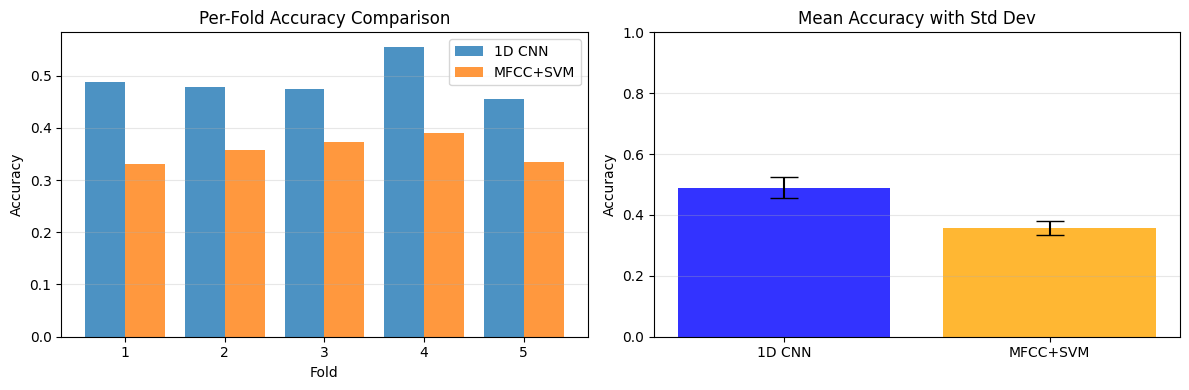

In [11]:
print('\n=== RESULTS COMPARISON ===')
print(f'1D CNN Mean Accuracy: {mean_cv:.4f} +/- {std_cv:.4f}')
print(f'MFCC+SVM Mean Accuracy: {baseline_mean:.4f} +/- {baseline_std:.4f}')
print(f'Improvement: +{(mean_cv - baseline_mean):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_pos = np.arange(5)
axes[0].bar(x_pos - 0.2, cv_results, 0.4, label='1D CNN', alpha=0.8)
axes[0].bar(x_pos + 0.2, baseline_results, 0.4, label='MFCC+SVM', alpha=0.8)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Per-Fold Accuracy Comparison')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['1', '2', '3', '4', '5'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

methods = ['1D CNN', 'MFCC+SVM']
means = [mean_cv, baseline_mean]
stds = [std_cv, baseline_std]
axes[1].bar(methods, means, yerr=stds, capsize=10, alpha=0.8, color=['blue', 'orange'])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Mean Accuracy with Std Dev')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Ablation Study: Hyperparameter Sensitivity

In [12]:
print('\n=== ABLATION STUDY ===')
print('Testing effect of different hyperparameters on fold 1')

ablation_results = {}

configs = {
    'baseline (lr=1e-3, b=8)': {'lr': 1e-3, 'batch': 8},
    'higher lr (lr=5e-3)': {'lr': 5e-3, 'batch': 8},
    'lower lr (lr=1e-4)': {'lr': 1e-4, 'batch': 8},
    'larger batch (b=16)': {'lr': 1e-3, 'batch': 16},
}

for config_name, config in configs.items():
    print(f'\nTesting: {config_name}')
    acc, _ = run_fold(
        csv_file=csv_file,
        audio_folder=audio_folder,
        val_fold=1,
        num_classes=50,
        batch_size=config['batch'],
        lr=config['lr'],
        epochs=10,
    )
    ablation_results[config_name] = acc
    print(f'Result: {acc:.4f}')

print('\n=== Ablation Results (ranked) ===')
for name, acc in sorted(ablation_results.items(), key=lambda x: x[1], reverse=True):
    print(f'{name:35s} {acc:.4f}')


=== ABLATION STUDY ===
Testing effect of different hyperparameters on fold 1

Testing: baseline (lr=1e-3, b=8)
Fold 1 Epoch 1
  train_loss 3.5401 train_acc 0.0931
  val_loss 3.2286 val_acc 0.1125
Fold 1 Epoch 2
  train_loss 3.0346 train_acc 0.165
  val_loss 2.8502 val_acc 0.205
Fold 1 Epoch 3
  train_loss 2.7771 train_acc 0.2306
  val_loss 2.7283 val_acc 0.2425
Fold 1 Epoch 4
  train_loss 2.6121 train_acc 0.2531
  val_loss 2.4985 val_acc 0.325
Fold 1 Epoch 5
  train_loss 2.4775 train_acc 0.295
  val_loss 2.4192 val_acc 0.3425
Fold 1 Epoch 6
  train_loss 2.3533 train_acc 0.335
  val_loss 2.3301 val_acc 0.37
Fold 1 Epoch 7
  train_loss 2.2331 train_acc 0.3619
  val_loss 2.2486 val_acc 0.3875
Fold 1 Epoch 8
  train_loss 2.1562 train_acc 0.3819
  val_loss 2.1413 val_acc 0.4225
Fold 1 Epoch 9
  train_loss 2.0275 train_acc 0.4188
  val_loss 2.2855 val_acc 0.4225
Fold 1 Epoch 10
  train_loss 1.9806 train_acc 0.4238
  val_loss 2.0318 val_acc 0.46
Result: 0.4600

Testing: higher lr (lr=5e-3)
F

## Final Summary

In [13]:
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print(f'\n1D CNN Raw Audio Architecture:')
print(f'  Input: 5 sec @ 16 kHz = 80,000 samples (mono waveform)')
print(f'  Stack: Conv1d(1->16->32->64->128->256)')
print(f'  Each block: Conv + BatchNorm + ReLU + MaxPool')
print(f'  Dropout (0.3) + Linear(256 -> 50 classes)')
print(f'\n5-Fold Cross-Validation:')
print(f'  Mean Accuracy: {mean_cv:.4f} +/- {std_cv:.4f}')
for i, acc in enumerate(cv_results, 1):
    print(f'  Fold {i}: {acc:.4f}')
print(f'\nBaseline (MFCC + RBF SVM):')
print(f'  Mean Accuracy: {baseline_mean:.4f} +/- {baseline_std:.4f}')
for i, acc in enumerate(baseline_results, 1):
    print(f'  Fold {i}: {acc:.4f}')
print(f'\nImprovement: +{(mean_cv - baseline_mean):.4f} ({((mean_cv - baseline_mean)/baseline_mean * 100):.2f}%)')
print(f'\nTraining Setup:')
print(f'  Augmentation: Time shift + amplitude scaling (training only)')
print(f'  Optimizer: Adam (lr=1e-3)')
print(f'  Loss: CrossEntropyLoss')
print(f'  Batch size: 8, Epochs: 15')
print(f'  Device: {device}')
print('\n' + '='*70)


FINAL RESULTS SUMMARY

1D CNN Raw Audio Architecture:
  Input: 5 sec @ 16 kHz = 80,000 samples (mono waveform)
  Stack: Conv1d(1->16->32->64->128->256)
  Each block: Conv + BatchNorm + ReLU + MaxPool
  Dropout (0.3) + Linear(256 -> 50 classes)

5-Fold Cross-Validation:
  Mean Accuracy: 0.4900 +/- 0.0342
  Fold 1: 0.4875
  Fold 2: 0.4775
  Fold 3: 0.4750
  Fold 4: 0.5550
  Fold 5: 0.4550

Baseline (MFCC + RBF SVM):
  Mean Accuracy: 0.3570 +/- 0.0225
  Fold 1: 0.3300
  Fold 2: 0.3575
  Fold 3: 0.3725
  Fold 4: 0.3900
  Fold 5: 0.3350

Improvement: +0.1330 (37.25%)

Training Setup:
  Augmentation: Time shift + amplitude scaling (training only)
  Optimizer: Adam (lr=1e-3)
  Loss: CrossEntropyLoss
  Batch size: 8, Epochs: 15
  Device: cpu

